### Lek transition time series

- Load territories data
- Make a stacked area plot showing the transition
- Plot scatter showing territories on both leks

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
import re

In [4]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [5]:
## Load territory data
terr = pd.read_csv('processed_data/territory_data.csv')

## Parse dates
terr['date'] = pd.to_datetime(terr['Date'], format="%Y-%b")

## Pivot to wide so we have one row per timepoint
wide = (terr.pivot_table(index='date', columns='Lek', values='Prop', aggfunc='mean').sort_index()
        .rename(columns={1: 'prop_lek1', 2: 'prop_lek2'}))
wide.head()

Lek,prop_lek1,prop_lek2
date,,
2013-12-01,1.000000,0.000000
2014-02-01,0.744898,0.255102
2014-10-01,0.973684,0.026316
2015-05-01,0.522013,0.477987
2015-11-01,0.720588,0.279412


In [6]:
## Colour palettes (match plot_stability.ipynb)
fill_cols = {'Velavadar Lek 1': '#2F7F7B', 'Velavadar Lek 2': '#6FB7B3'}
point_cols = {'Velavadar Lek 1': '#1F5F5B', 'Velavadar Lek 2': '#8FD0CC'}

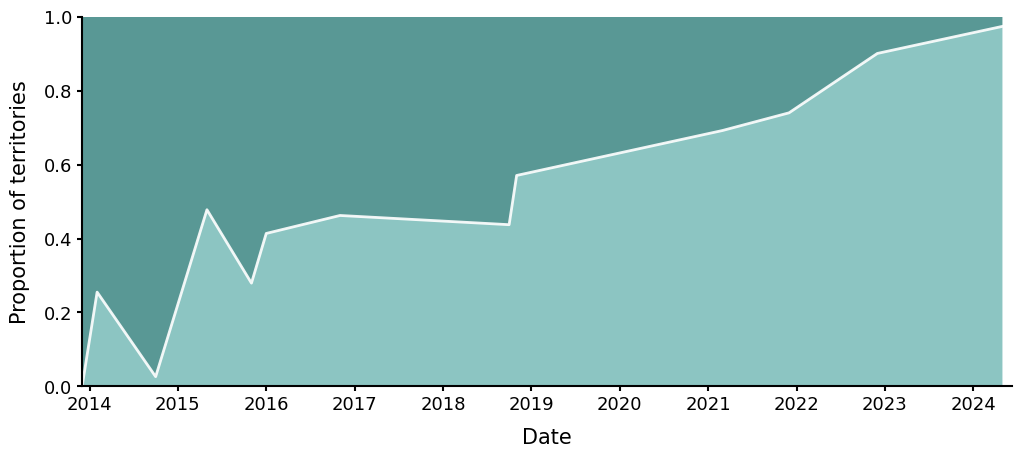

In [7]:
## Stacked area plot of territory proportions (Lek transition)

fig, ax = plt.subplots(figsize=(12, 4.8))

# Stacked areas (Lek 1 + Lek 2)
ax.stackplot(
    wide.index,
    wide["prop_lek2"].values,
    wide["prop_lek1"].values,
    colors=[fill_cols["Velavadar Lek 2"], fill_cols["Velavadar Lek 1"]],
    alpha=0.80
)

# Boundary between the two areas (i.e., prop_lek1)
ax.plot(wide.index, wide["prop_lek2"], color="#FFFFFF", linewidth=2, alpha=0.9)

# Match your figure styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xlabel('Date', fontsize=15, labelpad=10)
ax.set_ylabel('Proportion of territories', fontsize=15, labelpad=10)
ax.set_ylim(-0.02, 1.02)

# Direct labels at right edge (so no legend needed)
x_last = wide.index.max()
x_pad = pd.Timedelta(days=40)
ax.set_xlim(wide.index.min(), x_last + x_pad)
ax.set_ylim(0,1)

plt.savefig(out_dir/'transition_data.png', dpi=300, bbox_inches='tight')

In [19]:
base_dir = Path("rawdata/Velavadar")
out_dir = Path("output")

data_dirs = sorted([p for p in base_dir.glob("*_COORDINATES") if p.is_dir()])